# CQR Example — AirPassengers with StatsForecast and NeuralForecast

This notebook demonstrates **Conformalized Quantile Regression (CQR)** on
the classic AirPassengers dataset (144 monthly observations, 1949–1960)
with two different forecasting backends:

1. `StatsForecast` + `AutoARIMA` — quantiles come from the model's
   analytical level-based interval API.
2. `NeuralForecast` + `MLP(MQLoss)` — quantiles come from a neural
   network with an explicit quantile loss head.

CQR wraps a quantile-producing forecaster and post-hoc calibrates its
predicted quantile interval so that empirical coverage matches the
target `1 - alpha`. The conformal correction widens (or tightens) the
model's own quantile interval by a calibration-set residual quantile,
with no distributional assumptions.

We hold out the last 12 months as a true test set so we can compare
calibrated intervals against unseen truths.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.utils import AirPassengersDF

from neuralforecast import NeuralForecast
from neuralforecast.losses.pytorch import MQLoss
from neuralforecast.models import MLP

from conformal_ts.adapters.statsforecast import StatsForecastAdapter
from conformal_ts.adapters.neuralforecast import NeuralForecastAdapter
from conformal_ts.methods.cqr import ConformalizedQuantileRegression

/Users/marcopeix/dev/conformal-ts/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-08 12:10:16,080	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-05-08 12:10:16,201	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Load data and split into train / test

AirPassengers uses month-end timestamps, so `freq="ME"`. We hold out
the last 12 months as a test set; CQR is calibrated on cross-validation
folds drawn from the training portion only.

In [2]:
HORIZON = 12
FREQ = "ME"
SEASON_LENGTH = 12
ALPHA = 0.1  # 90% prediction intervals
N_WINDOWS = 24  # CV calibration windows
HOLDOUT = HORIZON  # last 12 months reserved as test set

df = AirPassengersDF.copy()
df["unique_id"] = df["unique_id"].astype(str)

train_df = df.iloc[:-HOLDOUT].copy()
test_df = df.iloc[-HOLDOUT:].copy()

print(
    f"Train: {len(train_df)} months ({train_df['ds'].min().date()} → {train_df['ds'].max().date()})"
)
print(f"Test:  {len(test_df)} months ({test_df['ds'].min().date()} → {test_df['ds'].max().date()})")
df.head()

Train: 132 months (1949-01-31 → 1959-12-31)
Test:  12 months (1960-01-31 → 1960-12-31)


,unique_id,ds,y
0,1.0,1949-01-31,112.0
1,1.0,1949-02-28,118.0
2,1.0,1949-03-31,132.0
3,1.0,1949-04-30,129.0
4,1.0,1949-05-31,121.0


## 1. CQR with StatsForecast + AutoARIMA

`AutoARIMA` produces analytical quantile intervals via its `level=` API
(`<model>-lo-90` / `<model>-hi-90` columns). `StatsForecastAdapter`
exposes those as `predict_quantiles` and `cross_validate_quantiles`,
which is everything CQR needs.

We pass `n_windows=24` to `calibrate(...)`: this triggers the
**cross-validation fast path**, where calibration runs in a single
library-native call instead of a Python loop over forecasts.

In [3]:
sf = StatsForecast(models=[AutoARIMA(season_length=SEASON_LENGTH)], freq=FREQ)
sf.fit(train_df)

sf_adapter = StatsForecastAdapter(
    sf=sf,
    train_df=train_df,
    horizon=HORIZON,
    freq=FREQ,
    model_name="AutoARIMA",
)

sf_cqr = ConformalizedQuantileRegression(sf_adapter, alpha=ALPHA)
sf_cal = sf_cqr.calibrate(n_windows=N_WINDOWS, step_size=1)

print(f"Calibration path:    {sf_cal.diagnostics['path']}")
print(f"Calibration windows: {sf_cal.n_calibration_samples}")
print(f"Quantiles used:      {sf_cal.diagnostics['quantiles_used']}")
print(f"Score quantile:      {sf_cal.score_quantile[0].round(1)}")

Calibration path:    cross_validation
Calibration windows: 24
Quantiles used:      [0.05, 0.95]
Score quantile:      [ 3.   8.7 13.3 15.2 12.  15.5 20.1 17.8 16.4  8.4  0.6  6.9]


In [4]:
# CQR predicts the next HORIZON months from the training history.
train_history = sf_adapter._df_to_panel(train_df, "y")  # (1, 132)
sf_result = sf_cqr.predict(train_history)

sf_summary = pd.DataFrame(
    {
        "date": test_df["ds"].values,
        "truth": test_df["y"].values,
        "lower_90": sf_result.interval[0, 0, :, 0].round(1),
        "point": sf_result.point[0, 0].round(1),
        "upper_90": sf_result.interval[0, 0, :, 1].round(1),
    }
)
sf_summary["covered"] = (sf_summary["truth"] >= sf_summary["lower_90"]) & (
    sf_summary["truth"] <= sf_summary["upper_90"]
)
print(f"Empirical coverage on holdout: {sf_summary['covered'].mean():.0%}")
sf_summary

Empirical coverage on holdout: 92%


,date,truth,lower_90,point,upper_90,covered
0,1960-01-31,417.0,403.9,424.1,444.3,True
1,1960-02-29,391.0,376.7,407.0,437.4,True
2,1960-03-31,419.0,431.7,470.8,509.9,False
3,1960-04-30,461.0,416.4,460.9,505.3,True
4,1960-05-31,472.0,440.5,484.9,529.2,True
5,1960-06-30,535.0,486.2,536.9,587.5,True
6,1960-07-31,622.0,554.9,612.9,670.8,True
7,1960-08-31,606.0,565.8,623.9,682.0,True
8,1960-09-30,508.0,468.8,527.9,586.9,True
9,1960-10-31,461.0,418.7,471.9,525.0,True


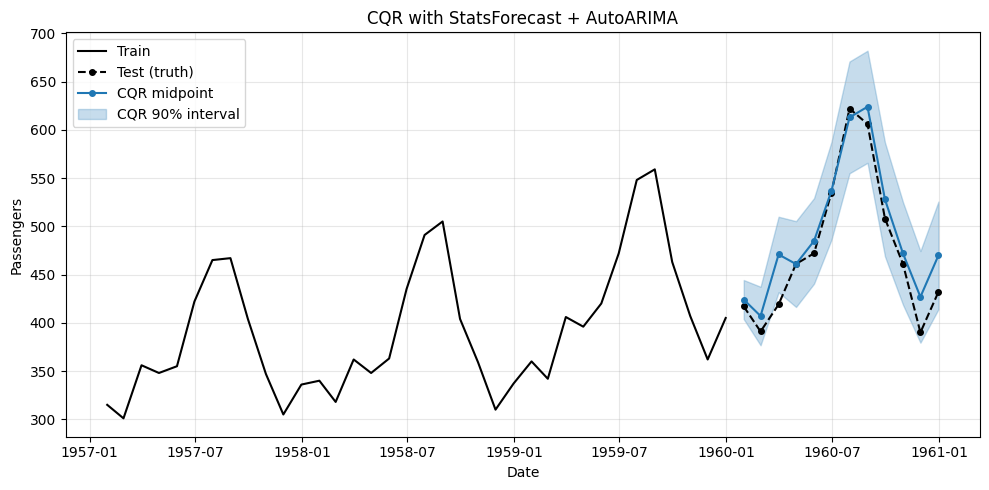

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

hist_window = 36
ax.plot(
    train_df["ds"].values[-hist_window:],
    train_df["y"].values[-hist_window:],
    color="black",
    label="Train",
)
ax.plot(
    test_df["ds"].values,
    test_df["y"].values,
    color="black",
    linestyle="--",
    marker="o",
    markersize=4,
    label="Test (truth)",
)
ax.plot(
    test_df["ds"].values,
    sf_result.point[0, 0],
    color="tab:blue",
    marker="o",
    markersize=4,
    label="CQR midpoint",
)
ax.fill_between(
    test_df["ds"].values,
    sf_result.interval[0, 0, :, 0],
    sf_result.interval[0, 0, :, 1],
    alpha=0.25,
    color="tab:blue",
    label=f"CQR {1 - ALPHA:.0%} interval",
)
ax.set_title("CQR with StatsForecast + AutoARIMA")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 2. CQR with NeuralForecast + MLP(MQLoss)

`MLP` doesn't have analytical intervals, so we equip it with `MQLoss`
and explicitly train it to predict the (0.05, 0.5, 0.95) quantiles. The
adapter detects the probabilistic loss at construction
(`_supports_quantiles_runtime = True`) and exposes `predict_quantiles`
and `cross_validate_quantiles` exactly as the StatsForecast adapter does.

We then drive CQR identically: same `calibrate(n_windows=...)` call,
same `predict(...)` call. The only thing that changes between the two
sections of this notebook is which adapter is wrapped.

In [6]:
_TRAINER_QUIET = dict(
    enable_progress_bar=False,
    enable_model_summary=False,
    logger=False,
    accelerator="cpu",
)

mlp = MLP(
    h=HORIZON,
    input_size=2 * SEASON_LENGTH,
    max_steps=400,
    loss=MQLoss(quantiles=[0.05, 0.5, 0.95]),
    random_seed=0,
    **_TRAINER_QUIET,
)
nf = NeuralForecast(models=[mlp], freq=FREQ)
nf.fit(train_df)

nf_adapter = NeuralForecastAdapter(
    nf=nf,
    train_df=train_df,
    freq=FREQ,
    model_name="MLP",
)

print(f"Loss class:                {nf_adapter._loss_class_name}")
print(f"Runtime quantile support:  {nf_adapter._supports_quantiles_runtime}")

nf_cqr = ConformalizedQuantileRegression(nf_adapter, alpha=ALPHA)
nf_cal = nf_cqr.calibrate(n_windows=N_WINDOWS, step_size=1)

print(f"Calibration path:    {nf_cal.diagnostics['path']}")
print(f"Calibration windows: {nf_cal.n_calibration_samples}")
print(f"Score quantile:      {nf_cal.score_quantile[0].round(1)}")

Seed set to 0
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/marcopeix/dev/conformal-ts/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=400` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/marcopeix/dev/conformal-ts/.venv/lib/python3.12/site-packages/pytorch_lightning/ut

Loss class:                MQLoss
Runtime quantile support:  True


`Trainer.fit` stopped: `max_steps=400` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Calibration path:    cross_validation
Calibration windows: 24
Score quantile:      [ 4.1  0.4  5.2 34.7 32.8 46.7 36.2 45.9 19.3 64.2 45.2 32.2]


In [7]:
train_history_nf = nf_adapter._df_to_panel(train_df, "y")
nf_result = nf_cqr.predict(train_history_nf)

nf_summary = pd.DataFrame(
    {
        "date": test_df["ds"].values,
        "truth": test_df["y"].values,
        "lower_90": nf_result.interval[0, 0, :, 0].round(1),
        "point": nf_result.point[0, 0].round(1),
        "upper_90": nf_result.interval[0, 0, :, 1].round(1),
    }
)
nf_summary["covered"] = (nf_summary["truth"] >= nf_summary["lower_90"]) & (
    nf_summary["truth"] <= nf_summary["upper_90"]
)
print(f"Empirical coverage on holdout: {nf_summary['covered'].mean():.0%}")
nf_summary

Empirical coverage on holdout: 92%


/Users/marcopeix/dev/conformal-ts/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


,date,truth,lower_90,point,upper_90,covered
0,1960-01-31,417.0,396.7,418.1,439.6,True
1,1960-02-29,391.0,375.7,415.8,455.9,True
2,1960-03-31,419.0,423.4,462.7,502.0,False
3,1960-04-30,461.0,428.9,492.3,555.7,True
4,1960-05-31,472.0,425.8,496.1,566.5,True
5,1960-06-30,535.0,517.2,568.1,619.0,True
6,1960-07-31,622.0,595.9,648.0,700.2,True
7,1960-08-31,606.0,589.0,647.4,705.7,True
8,1960-09-30,508.0,497.0,542.5,588.1,True
9,1960-10-31,461.0,415.3,483.9,552.4,True


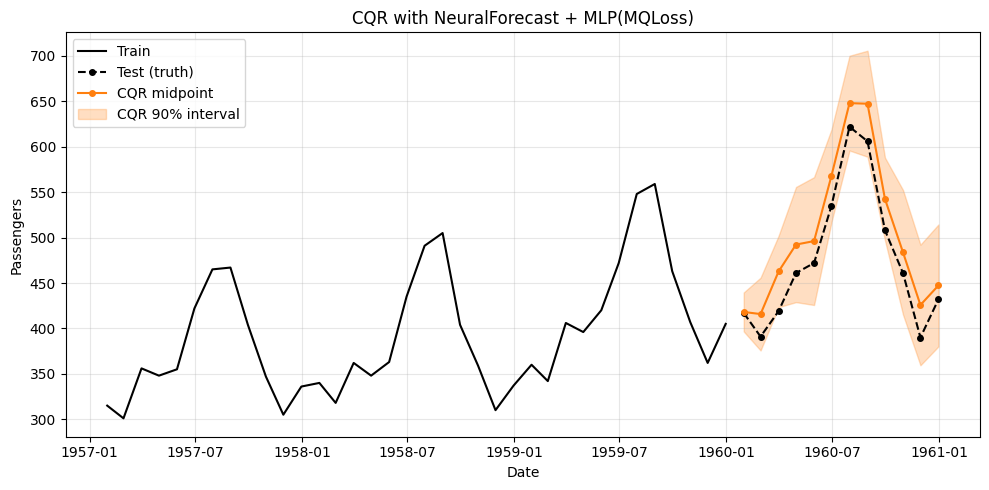

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    train_df["ds"].values[-hist_window:],
    train_df["y"].values[-hist_window:],
    color="black",
    label="Train",
)
ax.plot(
    test_df["ds"].values,
    test_df["y"].values,
    color="black",
    linestyle="--",
    marker="o",
    markersize=4,
    label="Test (truth)",
)
ax.plot(
    test_df["ds"].values,
    nf_result.point[0, 0],
    color="tab:orange",
    marker="o",
    markersize=4,
    label="CQR midpoint",
)
ax.fill_between(
    test_df["ds"].values,
    nf_result.interval[0, 0, :, 0],
    nf_result.interval[0, 0, :, 1],
    alpha=0.25,
    color="tab:orange",
    label=f"CQR {1 - ALPHA:.0%} interval",
)
ax.set_title("CQR with NeuralForecast + MLP(MQLoss)")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Side-by-side comparison

Both backends produce calibrated 90% intervals targeting the same
marginal coverage; the **shape** of the intervals differs because the
two models capture seasonality differently and CQR inherits the
model's own quantile shape, only adjusting it by a constant per horizon
step. AutoARIMA's analytical intervals fan out smoothly; the MLP
intervals reflect the learned quantile heads.

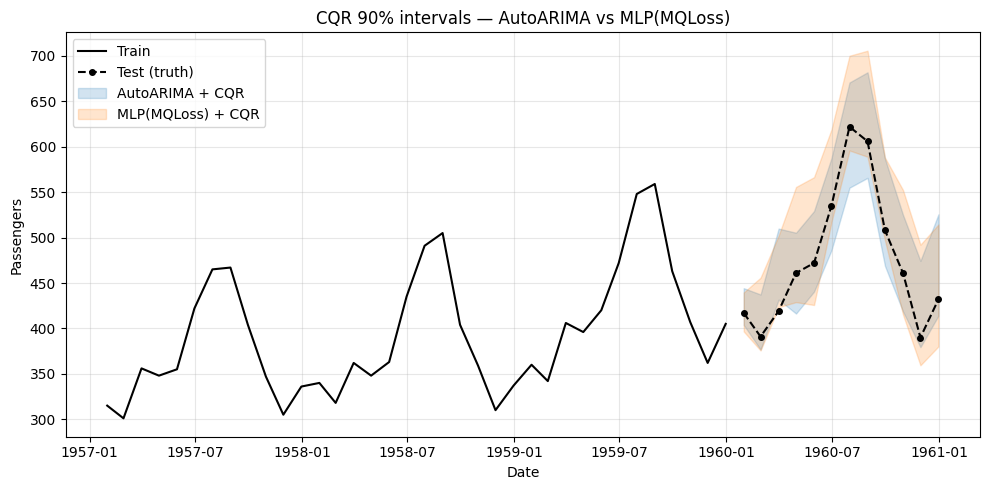

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    train_df["ds"].values[-hist_window:],
    train_df["y"].values[-hist_window:],
    color="black",
    label="Train",
)
ax.plot(
    test_df["ds"].values,
    test_df["y"].values,
    color="black",
    linestyle="--",
    marker="o",
    markersize=4,
    label="Test (truth)",
)

ax.fill_between(
    test_df["ds"].values,
    sf_result.interval[0, 0, :, 0],
    sf_result.interval[0, 0, :, 1],
    alpha=0.20,
    color="tab:blue",
    label="AutoARIMA + CQR",
)
ax.fill_between(
    test_df["ds"].values,
    nf_result.interval[0, 0, :, 0],
    nf_result.interval[0, 0, :, 1],
    alpha=0.20,
    color="tab:orange",
    label="MLP(MQLoss) + CQR",
)

ax.set_title(f"CQR {1 - ALPHA:.0%} intervals — AutoARIMA vs MLP(MQLoss)")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()